In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

In [7]:
df_collapsed = pd.read_csv("carnitines_final_table_diff_CHO.tsv", sep="\t")

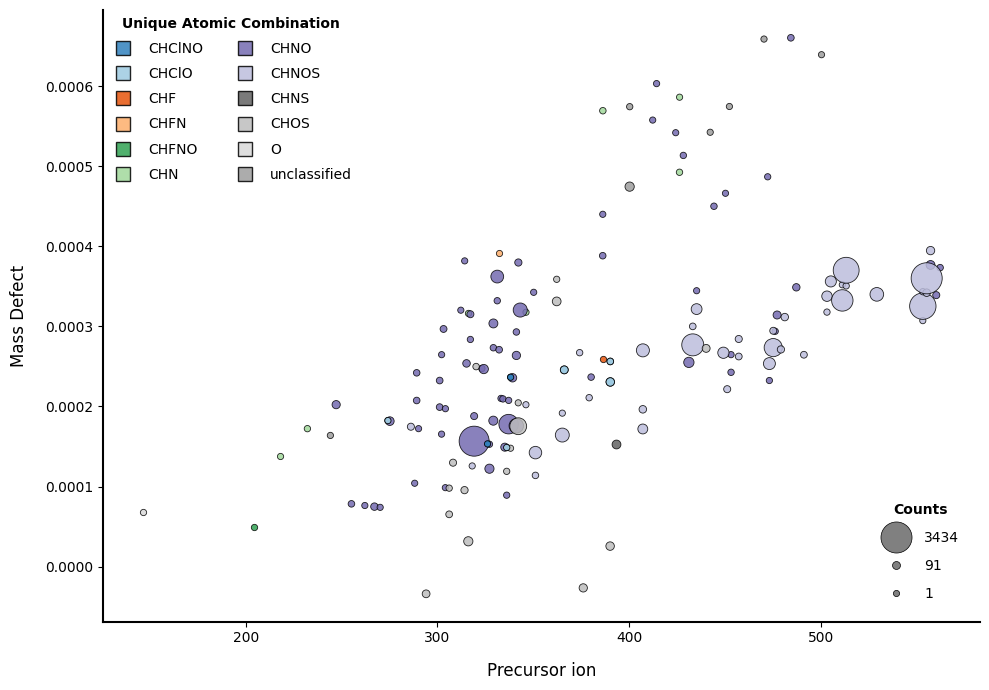

In [10]:
# --- START OF PLOT CODE ---

# 1) Scale 'counts' using linear normalization
min_counts = df_collapsed['counts'].min()
max_counts = df_collapsed['counts'].max()

# Define minimum and maximum point sizes
min_size = 20   # minimum point size
max_size = 500  # maximum point size

# Normalize counts to the new range
df_collapsed['scaled_counts'] = (
    min_size
    + (df_collapsed['counts'] - min_counts) * (max_size - min_size) / (max_counts - min_counts)
)

# 2) Build color palette for each unique combination (fix "unclassified" as gray)
unique_combinations = sorted(df_collapsed['delta_MF_unique_combination'].unique())
others = [c for c in unique_combinations if c != "unclassified"]
colors_others = plt.cm.tab20c(np.linspace(0, 1, len(others)))
color_map = dict(zip(others, colors_others))
if "unclassified" in unique_combinations:
    color_map["unclassified"] = (0.62, 0.62, 0.62, 1.0)  # ~ #9E9E9E

# 3) Figure setup
fig, ax = plt.subplots(figsize=(10, 7))

# 4) Scatter points with black edge
for combination, group in df_collapsed.groupby('delta_MF_unique_combination'):
    ax.scatter(
        group['precmz'],
        group['mass_defect'],
        s=group['scaled_counts'],
        c=[color_map[combination]],
        alpha=0.85,
        edgecolors='k',   # black edge
        linewidth=0.6
    )

# --- Re-plot on top only classes CHClO and CHClNO (no annotations) ---
for target_label in ["CHClO", "CHClNO"]:
    mask = df_collapsed['delta_MF_unique_combination'] == target_label
    if not mask.any():
        continue

    grp = df_collapsed.loc[mask, ['precmz', 'mass_defect', 'scaled_counts']]

    ax.scatter(
        grp['precmz'],
        grp['mass_defect'],
        s=grp['scaled_counts'],                   # keep the same size
        c=[color_map.get(target_label, "#9E9E9E")],
        alpha=0.95,                               # slightly more visible
        edgecolors='k',
        linewidth=0.6,
        zorder=6                                  # above the others
    )

# 5) Style and formatting
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.grid(False)

# Thicker axis lines
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

# Labels
ax.set_xlabel('Precursor ion', fontsize=12, labelpad=12)
ax.set_ylabel('Mass Defect', fontsize=12, labelpad=12)

# 6) Color legend (Combinations) in the upper-left corner
legend_handles_combinations = [
    plt.Line2D([0], [0], marker='s', color='none', markerfacecolor=color_map[comb],
               markersize=10, label=comb, markeredgecolor='k', alpha=0.85)
    for comb in unique_combinations
]
legend1 = ax.legend(
    handles=legend_handles_combinations,
    loc='upper left',
    frameon=False,
    labelspacing=0.8,
    borderpad=0,
    ncol=2
)
legend1.set_title("Unique Atomic Combination", prop={'weight': 'bold'})
legend1.get_title().set_ha('left')

# 7) Size legend (Counts) in the lower-right corner
sizes = df_collapsed['counts'].drop_duplicates().sort_values(ascending=False)
if len(sizes) > 3:
    sizes = sizes.iloc[[0, len(sizes)//2, -1]]
elif len(sizes) < 3:
    sizes = sizes.iloc[0:len(sizes)]

scaled_sizes = min_size + (sizes - min_counts) * (max_size - min_size) / (max_counts - min_counts)
legend_markers_counts = [
    plt.Line2D([0], [0], marker='o', color='none', markerfacecolor='gray',
               markersize=np.sqrt(s), label=str(int(size)),
               markeredgecolor='k', markeredgewidth=0.5)
    for s, size in zip(scaled_sizes, sizes)
]
legend2 = ax.legend(
    handles=legend_markers_counts,
    loc='lower right',
    frameon=False,
    labelspacing=1,
    borderpad=1,
    handletextpad=1,
)
legend2.set_title("Counts", prop={'weight': 'bold'})
legend2.get_title().set_ha('left')

# Add the first legend back
ax.add_artist(legend1)

plt.tight_layout()

# Export
# plt.savefig("mass_defect_plot_diff_CHO.png", dpi=600, bbox_inches='tight')
plt.savefig("Figure 1e.pdf", bbox_inches='tight')
plt.show()
